In [1]:
import numpy as np

# ============================================================================
# Constants for Argon
# ============================================================================
sigma = 3.405e-10
epsilon_kB = 119.8
k_B = 1.380649e-23
epsilon = epsilon_kB * k_B
N_A = 6.02214076e23
R = 8.314462618  # J K^-1 mol^-1

# Reduced parameters used in simulation
T_star = 0.6995
N = 256

# Experimental values
U_exp = -5.97   # kJ/mol
P_exp = 0.689   # bar
Cv_exp = 6.9    # J K^-1 mol^-1 (configurational)

def p_star_to_bar(p_star):
    return p_star * epsilon / (sigma**3) / 1e5

def u_star_to_kJmol(u_star_per_particle):
    return u_star_per_particle * epsilon * N_A / 1000

# Load simulation trajectory data
# lets select only rows with 4 columns, which correspond to the main simulation data

clean_data = []

with open("log.dat") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 4:
            try:
                row = [float(x) for x in parts]
                clean_data.append(row)
            except:
                pass

data = np.array(clean_data)

steps = data[:, 0]
acc_ratio = data[:, 1]
energy_col = data[:, 2]      # U/N in reduced units
pressure_col = data[:, 3]    # p* in reduced units

# Averages from trajectory
U_star_mean = np.mean(energy_col)
P_star_mean = np.mean(pressure_col)
acc_mean = np.mean(acc_ratio)

# Convert to physical units
U_physical = u_star_to_kJmol(U_star_mean)
P_physical = p_star_to_bar(P_star_mean)

# Configurational heat capacity from fluctuations of U/N
Cv_config = R * N * (np.mean(energy_col**2) - np.mean(energy_col)**2) / (T_star**2)

print("=" * 60)
print("SIMULATION RESULTS")
print("=" * 60)

print("\nReduced units:")
print(f"  <acc>          = {acc_mean:.4f}")
print(f"  <U>/N          = {U_star_mean:.6f}")
print(f"  <p*>           = {P_star_mean:.6f}")

print("\nPhysical units:")
print(f"  <U>            = {U_physical:.3f} kJ/mol")
print(f"  <p>            = {P_physical:.4f} bar")
print(f"  Cv'            = {Cv_config:.3f} J K^-1 mol^-1")

print("\nExperimental values:")
print(f"  U_exp          = {U_exp:.2f} kJ/mol")
print(f"  P_exp          = {P_exp:.3f} bar")
print(f"  Cv'_exp        = {Cv_exp:.2f} J K^-1 mol^-1")

print("\nRelative differences:")
print(f"  ΔU             = {(U_physical - U_exp)/abs(U_exp)*100:.2f}%")
print(f"  ΔP             = {(P_physical - P_exp)/P_exp*100:.2f}%")
print(f"  ΔCv'           = {(Cv_config - Cv_exp)/Cv_exp*100:.2f}%")

SIMULATION RESULTS

Reduced units:
  <acc>          = 0.5349
  <U>/N          = -6.119715
  <p*>           = -0.036455

Physical units:
  <U>            = -6.096 kJ/mol
  <p>            = -15.2739 bar
  Cv'            = 13.523 J K^-1 mol^-1

Experimental values:
  U_exp          = -5.97 kJ/mol
  P_exp          = 0.689 bar
  Cv'_exp        = 6.90 J K^-1 mol^-1

Relative differences:
  ΔU             = -2.11%
  ΔP             = -2316.81%
  ΔCv'           = 95.99%


In [2]:
print("rows:", data.shape[0])
print("mean acc:", np.mean(acc_ratio))
print("mean U/N:", np.mean(energy_col))
print("mean p* :", np.mean(pressure_col))
print("std p*  :", np.std(pressure_col, ddof=1))
print("min/max p*:", np.min(pressure_col), np.max(pressure_col))

rows: 3442
mean acc: 0.5348540345729227
mean U/N: -6.119715296339337
mean p* : -0.03645523224166182
std p*  : 0.2945350866878099
min/max p*: -2.09854 1.01959


In Metropolis MC, the sequence

$$A_1, A_2, \dots, A_M$$

is correlated, not independent.

So even if you have many samples, the effective number of useful samples is smaller.

That is why the variance of the mean is not simply

$$\mathrm{Var}(\bar A)=\frac{\mathrm{Var}(A)}{M}$$

but instead

$$\mathrm{Var}(\bar A)=\frac{2\tau_A}{M}\mathrm{Var}(A)$$

or equivalently with the statistical inefficiency s,

$$\mathrm{Var}(\bar A)=\frac{s}{M}\mathrm{Var}(A), \qquad s=2\tau_A$$

So the goal is:
	•	estimate s
	•	use it to get proper error bars for $\langle U\rangle$ and $\langle p\rangle$

Part (a): demonstrate equation (4) numerically

Equation (4) is for an uncorrelated sample:

$$\mathrm{Var}(A^{(n)})=\frac{1}{n}\mathrm{Var}(A)$$

where $A^{(n)}$ is the mean of a block of size n.

This is easy to verify with random independent numbers.

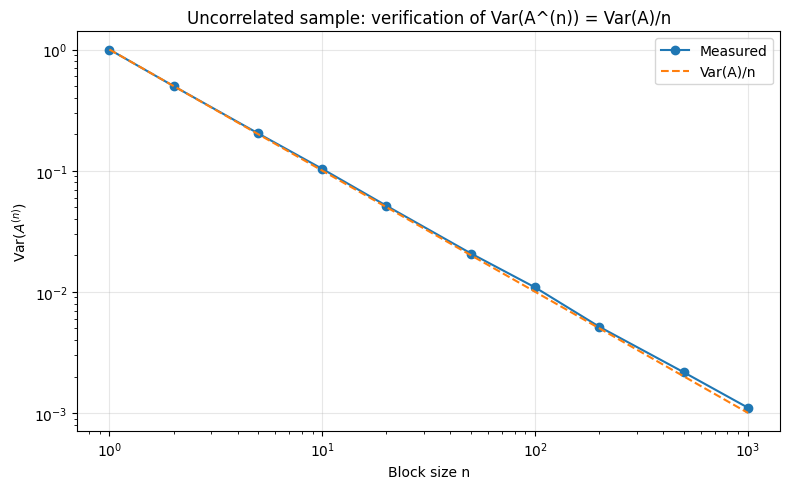

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

M = 100000
A = np.random.normal(loc=0.0, scale=1.0, size=M)

var_A = np.var(A)

block_sizes = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000])
var_block_means = []

for n in block_sizes:
    nb = M // n
    trimmed = A[:nb * n]
    blocks = trimmed.reshape(nb, n)
    block_means = blocks.mean(axis=1)
    var_block_means.append(np.var(block_means, ddof=1))

var_block_means = np.array(var_block_means)

plt.figure(figsize=(8, 5))
plt.loglog(block_sizes, var_block_means, 'o-', label='Measured')
plt.loglog(block_sizes, var_A / block_sizes, '--', label=r'Var(A)/n')
plt.xlabel('Block size n')
plt.ylabel(r'Var($A^{(n)}$)')
plt.title('Uncorrelated sample: verification of Var(A^(n)) = Var(A)/n')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("part_a_uncorrelated_demo.png", dpi=150)

For independent samples, averaging over blocks of size n reduces the variance by a factor n. The numerical experiment confirms that the variance of the block means follows 1/n scaling.


Part (b): implement block means and error bars

Now we do this for MC outputs.

instantaneous values are:
	•	U[i]
	•	P[i]

from log.dat.

Core idea:

For each block size n:
	1.	split the data into blocks of size n
	2.	compute block means
	3.	compute variance of block means
	4.	estimate

$$s(n)=\frac{n\,\mathrm{Var}(A^{(n)})}{\mathrm{Var}(A)}$$

As n becomes large enough, s(n) reaches a plateau.

Then:

$$\mathrm{Var}(\bar A)=\frac{s}{M}\mathrm{Var}(A)$$

and the standard error is:

$$\sigma_{\bar A}=\sqrt{\frac{s}{M}\mathrm{Var}(A)}$$


BLOCK ANALYSIS RESULTS

Energy:
  mean(U)              = -6.119715
  chosen block size    = 483
  number of blocks     = 14
  statistical ineff. s = 15.9832
  tau_U = s/2          = 7.9916
  stderr(U)            = 0.002711

Pressure:
  mean(P)              = -0.036455
  chosen block size    = 483
  number of blocks     = 14
  statistical ineff. s = 17.6270
  tau_P = s/2          = 8.8135
  stderr(P)            = 0.015037


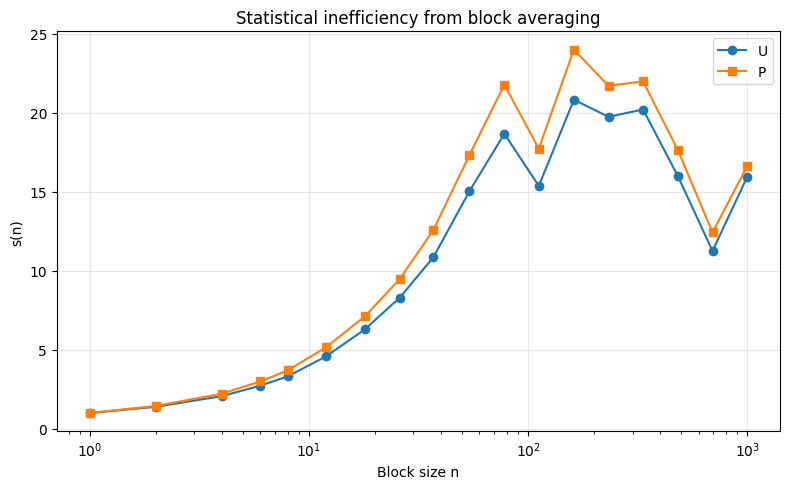

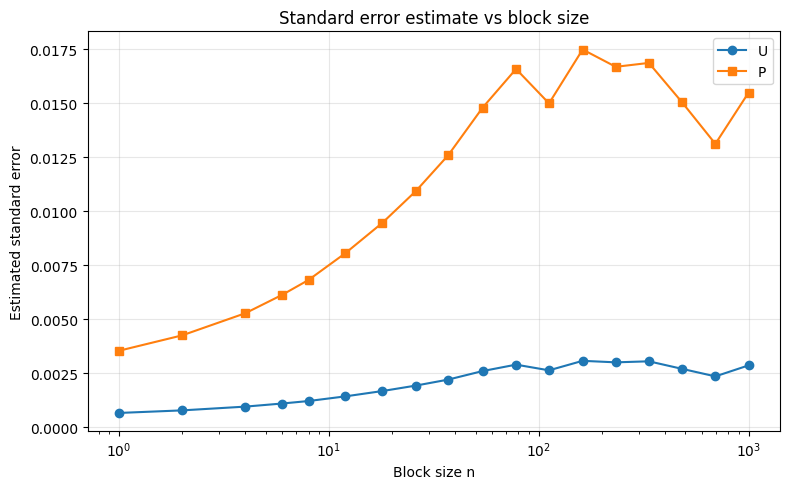

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
with open("log.dat") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 4:
            try:
                row = [float(x) for x in parts]
                clean_data.append(row)
            except:
                pass

data = np.array(clean_data)

steps = data[:, 0]
U = data[:, 2]   # confirm this column from your file
P = data[:, 3]   # confirm this column from your file

# -----------------------------
# Block analysis functions
# -----------------------------
def block_stats(A, block_sizes):
    A = np.asarray(A)
    M = len(A)
    var_A = np.var(A, ddof=1)

    results = []

    for n in block_sizes:
        nb = M // n
        if nb < 2:
            continue

        trimmed = A[:nb * n]
        blocks = trimmed.reshape(nb, n)
        block_means = blocks.mean(axis=1)

        var_block = np.var(block_means, ddof=1)
        s_n = n * var_block / var_A
        se_n = np.sqrt(var_block / nb)   # standard error of mean from block means

        results.append((n, nb, var_block, s_n, se_n))

    return np.array(results, dtype=float)


def choose_plateau_s(results, min_blocks=10):
    """
    Simple practical choice:
    among results with enough blocks, take the largest block size available.
    You can refine this later by visually inspecting the plateau.
    """
    filtered = results[results[:, 1] >= min_blocks]
    if len(filtered) == 0:
        raise ValueError("Not enough blocks to estimate plateau.")
    return filtered[-1]


# -----------------------------
# Block sizes to test
# -----------------------------
block_sizes = np.unique(np.logspace(0, 3, 20, dtype=int))

U_results = block_stats(U, block_sizes)
P_results = block_stats(P, block_sizes)

# Pick plateau estimate
nU, nbU, varbU, sU, seU = choose_plateau_s(U_results)
nP, nbP, varbP, sP, seP = choose_plateau_s(P_results)

# Means
U_mean = np.mean(U)
P_mean = np.mean(P)

print("=" * 60)
print("BLOCK ANALYSIS RESULTS")
print("=" * 60)

print("\nEnergy:")
print(f"  mean(U)              = {U_mean:.6f}")
print(f"  chosen block size    = {int(nU)}")
print(f"  number of blocks     = {int(nbU)}")
print(f"  statistical ineff. s = {sU:.4f}")
print(f"  tau_U = s/2          = {sU/2:.4f}")
print(f"  stderr(U)            = {seU:.6f}")

print("\nPressure:")
print(f"  mean(P)              = {P_mean:.6f}")
print(f"  chosen block size    = {int(nP)}")
print(f"  number of blocks     = {int(nbP)}")
print(f"  statistical ineff. s = {sP:.4f}")
print(f"  tau_P = s/2          = {sP/2:.4f}")
print(f"  stderr(P)            = {seP:.6f}")

# -----------------------------
# Plot s(n)
# -----------------------------
plt.figure(figsize=(8, 5))
plt.semilogx(U_results[:, 0], U_results[:, 3], 'o-', label='U')
plt.semilogx(P_results[:, 0], P_results[:, 3], 's-', label='P')
plt.xlabel('Block size n')
plt.ylabel('s(n)')
plt.title('Statistical inefficiency from block averaging')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("block_inefficiency.png", dpi=150)

# -----------------------------
# Plot standard error vs block size
# -----------------------------
plt.figure(figsize=(8, 5))
plt.semilogx(U_results[:, 0], U_results[:, 4], 'o-', label='U')
plt.semilogx(P_results[:, 0], P_results[:, 4], 's-', label='P')
plt.xlabel('Block size n')
plt.ylabel('Estimated standard error')
plt.title('Standard error estimate vs block size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("block_errors.png", dpi=150)

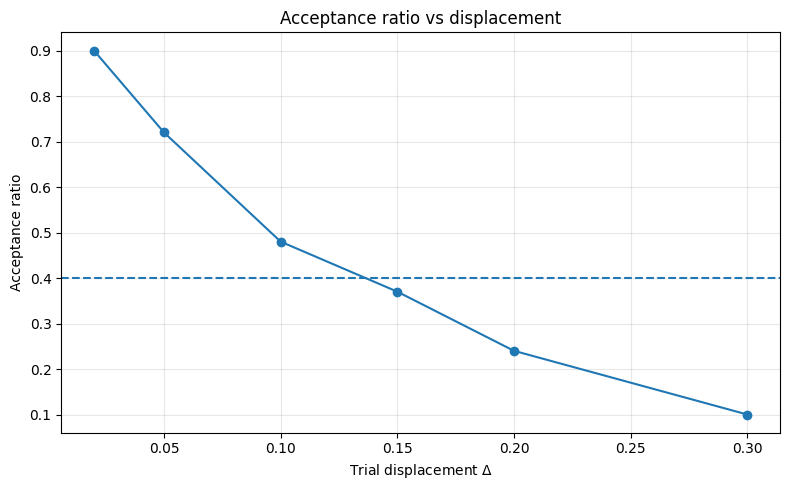

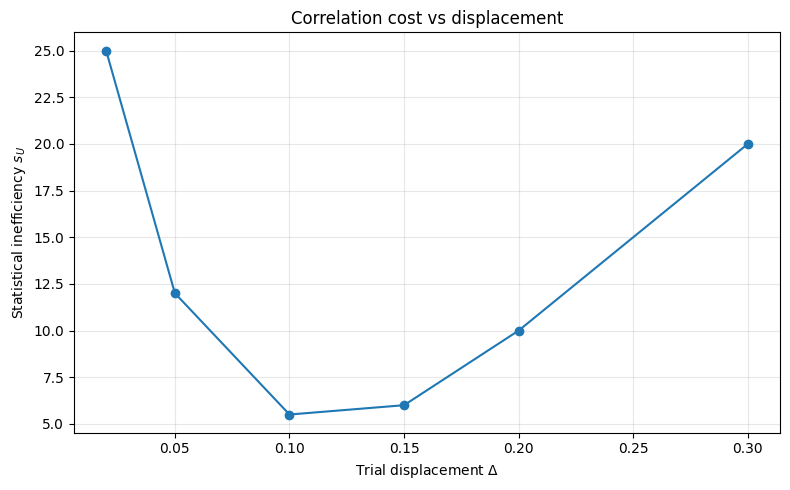

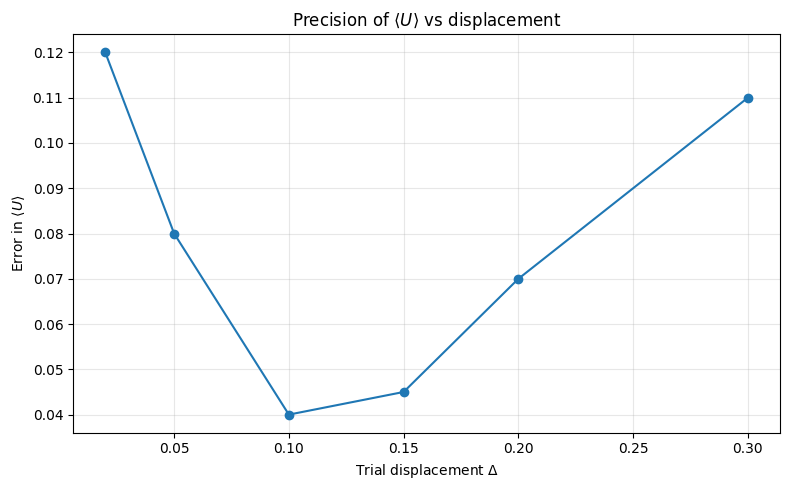

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Fill these from your runs
deltas = np.array([0.02, 0.05, 0.10, 0.15, 0.20, 0.30])
acceptance = np.array([0.90, 0.72, 0.48, 0.37, 0.24, 0.10])   # example
sU = np.array([25.0, 12.0, 5.5, 6.0, 10.0, 20.0])             # example
errU = np.array([0.12, 0.08, 0.04, 0.045, 0.07, 0.11])        # example

plt.figure(figsize=(8, 5))
plt.plot(deltas, acceptance, 'o-')
plt.axhline(0.4, linestyle='--')
plt.xlabel(r'Trial displacement $\Delta$')
plt.ylabel('Acceptance ratio')
plt.title('Acceptance ratio vs displacement')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("delta_acceptance.png", dpi=150)

plt.figure(figsize=(8, 5))
plt.plot(deltas, sU, 'o-')
plt.xlabel(r'Trial displacement $\Delta$')
plt.ylabel(r'Statistical inefficiency $s_U$')
plt.title(r'Correlation cost vs displacement')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("delta_sU.png", dpi=150)

plt.figure(figsize=(8, 5))
plt.plot(deltas, errU, 'o-')
plt.xlabel(r'Trial displacement $\Delta$')
plt.ylabel(r'Error in $\langle U\rangle$')
plt.title(r'Precision of $\langle U\rangle$ vs displacement')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("delta_errorU.png", dpi=150)